# ST4 — Corporate CapEx: Data Ingestion & Cleaning
**Team 7 Lambda | Phase 1 | Feb 27 – Mar 2**

**Goal:** Pull annual CapEx, R&D, and Revenue figures for 10 companies from the SEC EDGAR XBRL API.
Compute intensity ratios and save a clean panel dataset.

**Companies (by sector):**
- Semiconductors: NVDA, INTC, AMD
- Hyperscalers: MSFT, GOOGL, AMZN
- Energy: XOM, NEE
- Mining/Critical Minerals: ALB, MP

**Causal role:** ST4 captures how firms restructure investment (CapEx / R&D) in response to
supply chain pressure (ST1) amplified by geopolitical risk (ST2) and energy policy asymmetries (ST3).

**Output:** `data/processed/st4_capex.parquet`

**API:** No key required. `User-Agent` header must be set (loaded from `.env` via `config.py`).

In [1]:
!pip install python-dotenv

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install pycountry

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install pyarrow

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
import sys
import time
import requests
import pandas as pd
from fredapi import Fred

# This line ensures the notebook can find your 'src' folder from inside the 'notebooks' folder
sys.path.append(os.path.abspath('../..'))

# Import your team's custom utilities and secure config
from src.config import FRED_API_KEY
from src.utils import log, save_parquet

# Initialize FRED with the secure key
fred = Fred(api_key=FRED_API_KEY)

In [5]:
HEADERS = {'User-Agent': 'UniversityProject your.email@example.com'}

COMPANIES = {
    'NVDA': 'semiconductor', 'AMD': 'semiconductor', 'INTC': 'semiconductor',
    'GOOGL': 'hyperscaler', 'MSFT': 'hyperscaler', 'AMZN': 'hyperscaler',
    'TSLA': 'energy', 'XOM': 'energy', 'NEE': 'energy', 'ALB': 'mining'
}

CONCEPT_WATERFALLS = {
    'Revenues': [
        'Revenues', 
        'RevenueFromContractWithCustomerExcludingAssessedTax', 
        'SalesRevenueNet',                                     
        'SalesRevenueGoodsNet',
        'RevenueNet' 
    ],
    'CapEx': [
        'PaymentsToAcquirePropertyPlantAndEquipment',
        'PaymentsForPropertyPlantAndEquipment',
        'PaymentsForConstructionAndAcquisitionsOfPropertyPlantAndEquipment', 
        'CapitalExpenditures'
    ],
    'R&D': [
        'ResearchAndDevelopmentExpense',
        'ResearchAndDevelopmentExpenseExcludingAcquiredInProcessCost',
        'TechnologyAndContentExpense' 
    ]
}

In [6]:
def get_cik_mapping():
    url = "https://www.sec.gov/files/company_tickers.json"
    response = requests.get(url, headers=HEADERS)
    data = response.json()
    return {v['ticker']: str(v['cik_str']).zfill(10) for k, v in data.items()}

def fetch_concept_data(cik, concept):
    url = f"https://data.sec.gov/api/xbrl/companyconcept/CIK{cik}/us-gaap/{concept}.json"
    response = requests.get(url, headers=HEADERS)
    time.sleep(0.15) 
    
    if response.status_code == 200:
        data = response.json()
        if 'units' in data and 'USD' in data['units']:
            df = pd.DataFrame(data['units']['USD'])
            df = df[df['form'].isin(['10-Q', '10-K'])].copy()
            df['end'] = pd.to_datetime(df['end'])
            df = df.sort_values('filed').drop_duplicates(subset=['end'], keep='last')
            df = df[['end', 'val']].rename(columns={'val': concept})
            df.set_index('end', inplace=True)
            return df
    return pd.DataFrame()

def run_extraction_pipeline():
    ticker_to_cik = get_cik_mapping()
    all_company_data = []

    for ticker, sector in COMPANIES.items():
        log.info(f"Processing SEC data for {ticker}...")
        cik = ticker_to_cik.get(ticker)
        if not cik: continue

        company_dfs = []
        for standard_name, tags in CONCEPT_WATERFALLS.items():
            metric_df = pd.DataFrame()
            for tag in tags:
                df = fetch_concept_data(cik, tag)
                if not df.empty:
                    df.rename(columns={tag: standard_name}, inplace=True)
                    metric_df = df
                    break 
            if not metric_df.empty:
                company_dfs.append(metric_df)

        if company_dfs:
            merged_df = pd.concat(company_dfs, axis=1)
            # Hard rule applied: ffill(limit=2)
            merged_df = merged_df.resample('QE').last().ffill(limit=2)
            merged_df['Ticker'] = ticker
            merged_df['Sector'] = sector
            all_company_data.append(merged_df.reset_index())

    master_df = pd.concat(all_company_data, ignore_index=True)
    
    # Schema alignment
    rename_map = {'Ticker': 'ticker', 'Sector': 'sector', 'end': 'period', 
                  'Revenues': 'revenue', 'CapEx': 'capex', 'R&D': 'rd_expense'}
    master_df.rename(columns=rename_map, inplace=True)
    
    if 'capex' in master_df.columns and 'revenue' in master_df.columns:
        master_df['capex_intensity'] = master_df['capex'] / master_df['revenue']
    if 'rd_expense' in master_df.columns and 'revenue' in master_df.columns:
        master_df['rd_intensity'] = master_df['rd_expense'] / master_df['revenue']

    # Timeline filter
    master_df = master_df[(master_df['period'] >= '2010-01-01') & (master_df['period'] <= '2022-12-31')]
    
    expected_cols = ['ticker', 'sector', 'period', 'capex', 'revenue', 'rd_expense', 'capex_intensity', 'rd_intensity']
    final_cols = [col for col in expected_cols if col in master_df.columns]
    
    return master_df[final_cols].reset_index(drop=True)

def merge_fred_macro(sec_df):
    log.info("Fetching FRED series BOGZ1FA895050005Q (Total US CapEx)...")
    fred_series = fred.get_series('BOGZ1FA895050005Q')
    
    fred_df = pd.DataFrame({'period': fred_series.index, 'us_total_capex_millions': fred_series.values})
    fred_df['period'] = pd.to_datetime(fred_df['period'])
    fred_df.set_index('period', inplace=True)
    # Hard rule applied: ffill(limit=2)
    fred_df = fred_df.resample('QE').last().ffill(limit=2).reset_index()

    log.info("Merging SEC and FRED datasets...")
    return pd.merge(sec_df, fred_df, on='period', how='left')

In [7]:
# 1. Run the SEC Extraction
sec_data = run_extraction_pipeline()

# 2. Merge the FRED Macro baseline
final_dataset = merge_fred_macro(sec_data)

# 3. Save to the proper directory using the team's utility
OUTPUT_PATH = '../data/processed/ST4/st4_capex.parquet'
save_parquet(final_dataset, OUTPUT_PATH)

log.info(f"Ingestion complete. Final dataset saved to {OUTPUT_PATH}")
display(final_dataset.head()) # Shows a nice preview table in Jupyter

20:09:54 [INFO] Processing SEC data for NVDA...
20:09:55 [INFO] Processing SEC data for AMD...
20:09:57 [INFO] Processing SEC data for INTC...
20:09:59 [INFO] Processing SEC data for GOOGL...
20:10:02 [INFO] Processing SEC data for MSFT...
20:10:03 [INFO] Processing SEC data for AMZN...
20:10:07 [INFO] Processing SEC data for TSLA...
20:10:08 [INFO] Processing SEC data for XOM...
20:10:10 [INFO] Processing SEC data for NEE...
20:10:15 [INFO] Processing SEC data for ALB...
20:10:17 [INFO] Fetching FRED series BOGZ1FA895050005Q (Total US CapEx)...
20:10:20 [INFO] Merging SEC and FRED datasets...
20:10:20 [INFO] Saved ../data/processed/ST4/st4_capex.parquet: 468 rows × 9 cols → ../data/processed/ST4/st4_capex.parquet
20:10:20 [INFO] Ingestion complete. Final dataset saved to ../data/processed/ST4/st4_capex.parquet


,ticker,sector,period,capex,revenue,rd_expense,capex_intensity,rd_intensity,us_total_capex_millions
0,NVDA,semiconductor,2010-03-31,77601000.0,3.326445e+09,908851000.0,0.023329,0.273220,3623996.0
1,NVDA,semiconductor,2010-06-30,77601000.0,1.001813e+09,218105000.0,0.077461,0.217710,3770764.0
2,NVDA,semiconductor,2010-09-30,77601000.0,1.813021e+09,210635000.0,0.042802,0.116179,3867806.0
3,NVDA,semiconductor,2010-12-31,NaN,8.439120e+08,204527000.0,NaN,0.242356,3892007.0
4,NVDA,semiconductor,2011-03-31,97890000.0,3.543309e+09,848830000.0,0.027627,0.239559,3861338.0


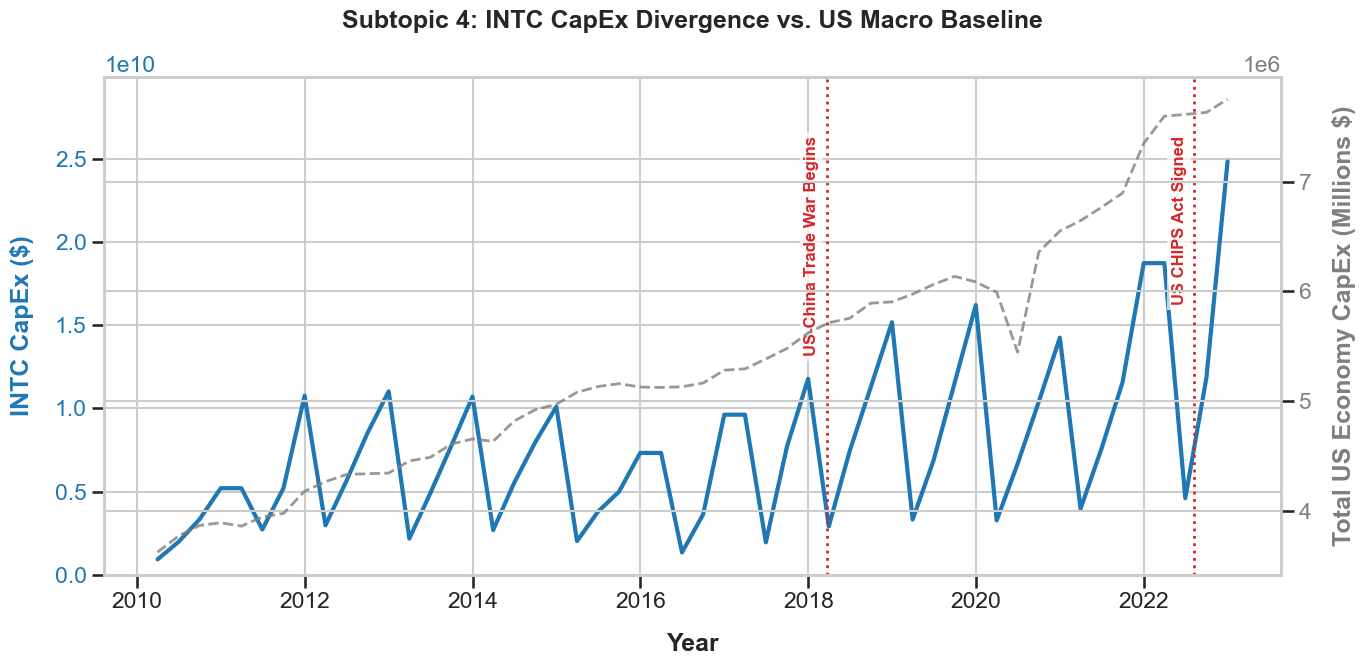

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Set up a clean, academic presentation style for your thesis
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")

# 2. Filter for a specific company to show the divergence
target_ticker = 'INTC'
# Drop rows where capex or the macro baseline is missing so the plot lines connect cleanly
company_data = final_dataset[final_dataset['ticker'] == target_ticker].dropna(subset=['capex', 'us_total_capex_millions']).copy()

fig, ax1 = plt.subplots(figsize=(14, 7))

# Axis 1: Company CapEx (Left Y-Axis - Blue Line)
color = '#1f77b4'
ax1.set_xlabel('Year', fontweight='bold', labelpad=15)
ax1.set_ylabel(f'{target_ticker} CapEx ($)', color=color, fontweight='bold', labelpad=15)
ax1.plot(company_data['period'], company_data['capex'], color=color, linewidth=3, label=f'{target_ticker} CapEx Restructuring')
ax1.tick_params(axis='y', labelcolor=color)

# Axis 2: US Total CapEx Baseline (Right Y-Axis - Gray Dashed Line)
ax2 = ax1.twinx()  
color = '#7f7f7f'
ax2.set_ylabel('Total US Economy CapEx (Millions $)', color=color, fontweight='bold', labelpad=15)  
ax2.plot(company_data['period'], company_data['us_total_capex_millions'], color=color, linestyle='--', linewidth=2, alpha=0.8, label='US Macro Baseline (FRED)')
ax2.tick_params(axis='y', labelcolor=color)

# 3. Add Geopolitical Event Markers (The "Why" behind the data)
events = {
    '2018-03-22': 'US-China Trade War Begins',
    '2022-08-09': 'US CHIPS Act Signed'
}

# Add 15% extra headroom to the top of the left Y-axis to prevent text collisions
ax1.set_ylim(bottom=0, top=ax1.get_ylim()[1] * 1.15)

for date_str, label in events.items():
    event_date = pd.to_datetime(date_str)
    
    # Only plot the line if the event falls within our timeline
    if event_date <= company_data['period'].max():
        ax1.axvline(event_date, color='#d62728', linestyle=':', linewidth=2)
        
        # Lowered to 0.75, shifted slightly left, anchored to the top, and added a readability box
        ax1.text(event_date - pd.DateOffset(days=100), ax1.get_ylim()[1] * 0.95, 
                 label, color='#d62728', fontsize=12, rotation=90, fontweight='bold',
                 va='top', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=3))

# Increased title padding from 20 to 35 to give it more breathing room
plt.title(f'Subtopic 4: {target_ticker} CapEx Divergence vs. US Macro Baseline', fontweight='bold', pad=35, fontsize=18)
fig.tight_layout()  

# plt.savefig('../data/processed/ST4/intel_divergence_chart.png', dpi=300)
plt.show()